# KLASIFIKASI GENRE GAME BERDASARKAN SINOPSIS
---
**Author:** *Muhammad Wira Widhana [24.55.2717]*

## Library & Load Dataset

library 

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import confusion_matrix, classification_report



In [25]:
# pertama kali saja:
"""
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
"""
# digunakan di preprocessing
english_stopwords = set(stopwords.words('english'))
stemmer = PorterStemmer()

## Load dan Memeriksa Data (Data Loading & EDA)

Load Dataset

In [26]:
# Load Dataset

df_raw = pd.read_csv('games_fixed.csv')

print("Ukuran awal dataset:", df_raw.shape)
df_raw.head()

Ukuran awal dataset: (122611, 36)


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Median playtime two weeks,Average playtime forever,Median playtime forever,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,10,Counter-Strike,"Nov 1, 2000",10000000 - 20000000,7323,0,1.99,80,0,Play the world's number 1 online action game. ...,...,99,10735,185,['Valve'],['Valve'],"['Multi-player', 'PvP', 'Online PvP', 'Shared/...",['Action'],"{'Action': 5504, 'FPS': 4929, 'Multiplayer': 3...",['https://shared.akamai.steamstatic.com/store_...,[]
1,100,Counter-Strike: Condition Zero,"Mar 1, 2004",10000000 - 20000000,83,0,1.99,80,0,"With its extensive Tour of Duty campaign, a ne...",...,1,431,32,['Valve'],['Valve'],"['Single-player', 'Multi-player', 'Color Alter...",['Action'],"{'Action': 1339, 'FPS': 979, 'Shooter': 723, '...",['https://shared.akamai.steamstatic.com/store_...,[]
2,1000000,ASCENXION,"May 14, 2021",0 - 20000,0,0,1.49,0,1,ASCENXION is a 2D shoot 'em up game where you ...,...,0,0,0,['IndigoBlue Game Studio'],['PsychoFlux Entertainment'],"['Single-player', 'Steam Achievements', 'Parti...","['Action', 'Adventure', 'Indie']","{""Shoot 'Em Up"": 186, 'Metroidvania': 181, 'Bu...",['https://shared.akamai.steamstatic.com/store_...,[]
3,1000010,Crown Trick,"Oct 16, 2020",500000 - 1000000,14,0,4.99,0,2,Crown Trick is a beautifully animated rogue-li...,...,0,702,397,['NEXT Studios'],"['Team17', 'NEXT Studios']","['Single-player', 'Steam Achievements', 'Steam...","['Adventure', 'Indie', 'RPG', 'Strategy']","{'Rogue-like': 275, 'Turn-Based Combat': 258, ...",['https://shared.akamai.steamstatic.com/store_...,[]
4,1000030,"Cook, Serve, Delicious! 3?!","Oct 14, 2020",100000 - 200000,27,0,4.99,75,1,Hit the road in this massive sequel to the mil...,...,0,281,118,['Vertigo Gaming Inc.'],['Vertigo Gaming Inc.'],"['Single-player', 'Multi-player', 'Co-op', 'Sh...","['Action', 'Indie', 'Simulation', 'Strategy']","{'Typing': 227, 'Management': 219, 'Difficult'...",['https://shared.akamai.steamstatic.com/store_...,[]


Exploratory Data Analysis (EDA)

In [27]:
# Exploratory Data Analysis (EDA)

df = df_raw[['Name', 'About the game', 'Genres']].copy()

df.rename(columns={
    'Name': 'title',
    'About the game': 'synopsis',
    'Genres': 'genre'
}, inplace=True)

print("Jumlah data setelah seleksi kolom:", df.shape)
df.sample(5)

Jumlah data setelah seleksi kolom: (122611, 3)


,title,synopsis,genre
60128,Folk Emerging Playtest,NaN,[]
75671,人类终结之日——2074,Game Story Background A disaster that could ha...,"['Adventure', 'RPG']"
112048,Onironauta,The game is avaible in italian language only! ...,"['Adventure', 'Indie']"
21011,Dead Seater,"You are Jesse, a man on a desperate mission to...","['Action', 'Adventure', 'Indie']"
33645,One Night With Stalin,One Night With Stalin is an indie horror game ...,"['Action', 'Adventure', 'Indie', 'Simulation']"


Cek missing values

In [28]:
# Cek missing values
df.isna().sum()

title          1
synopsis    8448
genre          0
dtype: int64

Hapus baris yang tidak punya sinopsis atau genre

In [29]:
# Hapus baris yang tidak punya sinopsis atau genre
df = df.dropna(subset=['synopsis', 'genre']).reset_index(drop=True)
print("Jumlah data setelah drop:", df.shape)

Jumlah data setelah drop: (114163, 3)


Distribusi jumlah genre

genre
['Casual', 'Indie']                           6698
['Action', 'Indie']                           5669
['Action', 'Adventure', 'Indie']              5149
['Adventure', 'Indie']                        4302
['Adventure', 'Casual', 'Indie']              3604
['Action', 'Casual', 'Indie']                 3421
['Casual']                                    3349
['Indie']                                     3073
['Action']                                    2949
['Casual', 'Indie', 'Strategy']               2245
['Casual', 'Indie', 'Simulation']             2184
['Adventure']                                 2124
['Action', 'Adventure', 'Casual', 'Indie']    2056
['Action', 'Adventure']                       1649
['Adventure', 'Casual']                       1585
['Adventure', 'Indie', 'RPG']                 1538
['Action', 'Adventure', 'Indie', 'RPG']       1530
['Strategy']                                  1356
['Indie', 'Strategy']                         1223
['Simulation']           

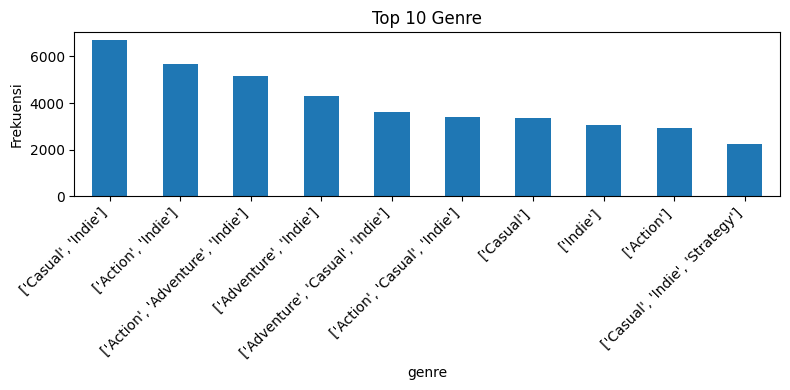

In [30]:
# Distribusi jumlah genre
print(df['genre'].value_counts().head(20))

plt.figure(figsize=(8,4))
df['genre'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Genre')
plt.ylabel('Frekuensi')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Filter Bahasa Inggris & Text Cleaning

Data Steam pada umumnya sudah bahasa Inggris di kolom sinopsis, namun kita tetap melakukan filter sederhana berbasis karakter dan pola bahasa.

In [31]:
# TEXT CLEANING & LANGUAGE FILTERING (ENGLISH-ONLY)

def basic_english_filter(text):
    """
    Filter kasar untuk mendeteksi teks yang dominan huruf Latin a-z,
    tanpa karakter non Latin yang signifikan. Pendekatan ini cukup
    untuk dataset Steam yang mayoritas berbahasa Inggris.
    """
    if not isinstance(text, str):
        return False
    
    # Hilangkan angka dan tanda baca, sisakan huruf dan spasi
    clean = re.sub(r'[^A-Za-z\s]', ' ', text)
    clean = re.sub(r'\s+', ' ', clean).strip()
    
    # Jika setelah dibersihkan terlalu pendek, anggap tidak valid
    if len(clean.split()) < 3:
        return False
    
    # Rasio huruf latin terhadap total karakter asli,
    # jika terlalu rendah berarti banyak simbol/non latin
    ratio = len(clean) / max(len(text), 1)
    return ratio >= 0.7

# Terapkan filter bahasa Inggris
df['is_english'] = df['synopsis'].apply(basic_english_filter)
print(df['is_english'].value_counts())

df = df[df['is_english']].drop(columns=['is_english']).reset_index(drop=True)
print("Jumlah data setelah filter bahasa Inggris:", df.shape)

is_english
True     112109
False      2054
Name: count, dtype: int64
Jumlah data setelah filter bahasa Inggris: (112109, 3)


Penghapusan Sinopsis Terlalu Pendek

menganalisis distribusi panjang sinopsis dan menetapkan ambang batas minimal berdasarkan persentil ke-5.

In [32]:
# SHORT SYNOPSIS REMOVAL BASED ON LENGTH DISTRIBUTION

# Hitung jumlah kata per sinopsis sebelum preprocessing berat
df['word_count'] = df['synopsis'].apply(lambda x: len(str(x).split()))

print(df['word_count'].describe())

p5  = np.percentile(df['word_count'], 5)
p10 = np.percentile(df['word_count'], 10)

print(f"Persentil ke-5  : {p5:.0f} kata")
print(f"Persentil ke-10 : {p10:.0f} kata")

count    112109.000000
mean        217.219991
std         164.280734
min           3.000000
25%         116.000000
50%         179.000000
75%         272.000000
max       11530.000000
Name: word_count, dtype: float64
Persentil ke-5  : 60 kata
Persentil ke-10 : 77 kata


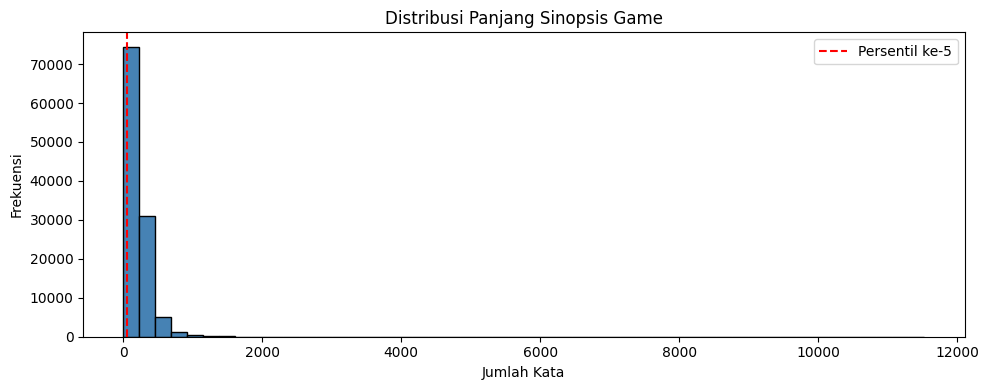

In [33]:
plt.figure(figsize=(10,4))
plt.hist(df['word_count'], bins=50, color='steelblue', edgecolor='black')
plt.axvline(p5, color='red', linestyle='--', label='Persentil ke-5')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.title('Distribusi Panjang Sinopsis Game')
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
# Tetapkan threshold minimum berdasarkan persentil ke-5
threshold = int(p5)
print("Threshold minimum panjang sinopsis:", threshold, "kata")

before = len(df)
df = df[df['word_count'] >= threshold].reset_index(drop=True)
after = len(df)

print("Data sebelum filtering :", before)
print("Data setelah filtering  :", after)
print("Data yang dihapus       :", before - after, f"({(before-after)/before*100:.2f}%)")

# Buang kolom bantu word_count (dihitung ulang jika perlu)
df = df.drop(columns=['word_count'])

Threshold minimum panjang sinopsis: 60 kata
Data sebelum filtering : 112109
Data setelah filtering  : 106647
Data yang dihapus       : 5462 (4.87%)


In [35]:
# MAPPING BUNDLE GENRE → SATU GENRE UTAMA (SINGLE-LABEL SESUAI PROPOSAL)
# mengubah genre yang berupa bundle (misal "Action, Adventure") menjadi satu genre
main_genres = ['Action', 'Adventure', 'RPG', 'Simulation', 'Casual', 'Indie']

def map_main_genre(g):
    if not isinstance(g, str):
        return None
    tags = [x.strip() for x in g.split(',')]
    for mg in main_genres:      # prioritas sesuai urutan di atas
        if mg in tags:
            return mg
    return None                  # buang jika tidak mengandung genre utama

df['genre_main'] = df['genre'].apply(map_main_genre)
df = df[~df['genre_main'].isna()].reset_index(drop=True)
df['genre'] = df['genre_main']
df = df.drop(columns=['genre_main'])

print("Genre utama tersisa:", df['genre'].value_counts())

Genre utama tersisa: Series([], Name: count, dtype: int64)


## PRE-Prosessing


preprocessing mencakup case folding, tokenizing, stopword removal, dan stemming, dan batasan masalah perubahan kombinasi fitur preprocessing.

Skenario:

- S1: Case folding + tokenizing + stopword removal

- S2: Case folding + tokenizing + stemming

- S3: Case folding + tokenizing + stopword removal + stemming

In [38]:
# PREPROCESSING SCENARIOS (S1, S2, S3)

def case_folding(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)  # hanya huruf a-z dan spasi
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize(text):
    return word_tokenize(text)

def remove_stopwords(tokens):
    return [t for t in tokens if t not in english_stopwords]

def stem_tokens(tokens):
    return [stemmer.stem(t) for t in tokens]

def preprocess(text, use_stopword=True, use_stemming=True):
    text = case_folding(text)
    tokens = tokenize(text)
    if use_stopword:
        tokens = remove_stopwords(tokens)
    if use_stemming:
        tokens = stem_tokens(tokens)
    return ' '.join(tokens)

# Skenario 1: stopword removal 
df['synopsis_S1'] = df['synopsis'].apply(lambda x: preprocess(x, use_stopword=True,  use_stemming=False))

# Skenario 2: stemming
df['synopsis_S2'] = df['synopsis'].apply(lambda x: preprocess(x, use_stopword=False, use_stemming=True))

# Skenario 3: stopword removal + stemming
df['synopsis_S3'] = df['synopsis'].apply(lambda x: preprocess(x, use_stopword=True,  use_stemming=True))

df[['title', 'genre', 'synopsis']].head(3)

,title,genre,synopsis


Feature Extraction with TF-IDF

In [37]:
# FEATURE EXTRACTION WITH TF-IDF

# Pilih salah satu skenario untuk eksperimen awal, misal S3 (pipeline penuh)
TEXT_COL = 'synopsis_S3'

X_text = df[TEXT_COL]
y = df['genre']

print("Contoh teks setelah preprocessing:")
print(X_text.iloc[0])
print("Label genre:", y.iloc[0])

Contoh teks setelah preprocessing:


IndexError: single positional indexer is out-of-bounds

## Modeling & Training

In [ ]:
# MAPPING BUNDLE GENRE → SATU GENRE UTAMA (SINGLE-LABEL SESUAI PROPOSAL)

main_genres = ['Action', 'Adventure', 'RPG', 'Simulation', 'Casual', 'Indie']

def map_main_genre(g):
    if not isinstance(g, str):
        return None
    tags = [x.strip() for x in g.split(',')]
    for mg in main_genres:      # prioritas sesuai urutan di atas
        if mg in tags:
            return mg
    return None                  # buang jika tidak mengandung genre utama

df['genre_main'] = df['genre'].apply(map_main_genre)
df = df[~df['genre_main'].isna()].reset_index(drop=True)
df['genre'] = df['genre_main']
df = df.drop(columns=['genre_main'])

print("Genre utama tersisa:", df['genre'].value_counts())

In [ ]:
# DAFTAR KELAS GENRE YANG TERSISA

genre_summary = y.value_counts().reset_index()
genre_summary.columns = ['Genre', 'Jumlah Sampel']
genre_summary.index += 1  # nomor urut mulai dari 1

print(f"Total kelas genre tersisa : {y.nunique()}")
print(f"Total sampel              : {len(y)}\n")
print(genre_summary.to_string())

Spliting model sebelum train spliting data menjadi 80 20


`test_size=0.2` 20% data untuk test

Sisanya 80% untuk model train

In [ ]:
# TRAIN TEST SPLIT
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print("Jumlah data train:", X_train_text.shape[0])
print("Jumlah data test :", X_test_text.shape[0])

In [ ]:
# TF-IDF: fit hanya pada data train (mencegah data leakage)
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)  # unigram + bigram
)

X_train = tfidf.fit_transform(X_train_text)
X_test  = tfidf.transform(X_test_text)

X_train.shape, X_test.shape

Model Naive Bayes

In [ ]:
# NAIVE BAYES

nb_clf = MultinomialNB()
nb_clf.fit(X_train, y_train)

y_pred_nb = nb_clf.predict(X_test)

Model K-Nearest Neighbors

In [ ]:
# K-NEAREST NEIGHBORS

# K bisa disesuaikan, misal k=19 mengacu Putra et al. (2024) untuk kasus anime
knn_clf = KNeighborsClassifier(n_neighbors=19, metric='cosine')
knn_clf.fit(X_train, y_train)

y_pred_knn = knn_clf.predict(X_test)

Model Support Vector Machine

In [ ]:
# SUPPORT VECTOR MACHINE 

svm_clf = LinearSVC()
svm_clf.fit(X_train, y_train)

y_pred_svm = svm_clf.predict(X_test)

## Evaluasi Model


In [ ]:
# FUNGSI BANTU EVALUASI

def evaluate_model(y_true, y_pred, model_name):
    print("="*80)
    print(f"MODEL: {model_name}")
    print("="*80)
    
    # Classification report: precision, recall, f1-score per kelas
    print(classification_report(y_true, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=sorted(y_true.unique()))
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=False, cmap='Blues',
                xticklabels=sorted(y_true.unique()),
                yticklabels=sorted(y_true.unique()))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.tight_layout()
    plt.show()

In [ ]:
# EVALUASI KETIGA MODEL

evaluate_model(y_test, y_pred_nb,  'Naive Bayes')
evaluate_model(y_test, y_pred_knn, 'K-Nearest Neighbors')
evaluate_model(y_test, y_pred_svm, 'Support Vector Machine')

## Implementasi